Implied Volatalities are obtained by solving the equation:
$$ C_{BS}(\sigma_{imp}) = C$$
In our model, the cost of an call option is found using Monte Carlo methods. After that, we use one of python's root finders to solve the above equation and find a root at $\sigma_{imp}$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, poisson
import yfinance as yf
from scipy.optimize import least_squares
from scipy.optimize import root_scalar

S0 = 100
T = 2
N = 252
sigma = 0.15
n_paths = 5000
r = 0.05 
dt = T / N
#We now want call option price as a function of the Strike price 
#Using Monte Carlo methods
def Call_Price(K, beta=0):
    Z = np.random.randn(n_paths, N)
    paths = np.zeros((n_paths, N + 1))
    paths[:, 0] = S0

    for t in range(N):
        S_t = paths[:, t]

        #Next discrete step using our standard normal distribution and current stock price (Markov process)
        paths[:, t+1] = S_t + (r * S_t * dt + sigma * (S_t ** (beta+1)) * np.sqrt(dt) * Z[:, t])

        #We don't want stock value to go below 0
        paths[:, t+1] = np.maximum(paths[:, t+1], 0)

    Value_at_expiry = np.exp(-r*T)*np.maximum(0,paths[:,-1]-K) #value at expiry discounted to current time.
    return np.mean(Value_at_expiry)


#BS Call price function from lecture
def bs_call(S,K,sigma,t,r):
    d1 = (np.log(S/K)+(r+(0.5)*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)

    call_price = S*norm.cdf(d1)-np.exp(-r*t)*K*norm.cdf(d2)

    return call_price
strike = np.arange(60, 150, 2)
betas = [-0.3,-0.2,-0.1, 0, 0.1, 0.2, 0.3]

cp = []
for beta in betas:
    cp_beta = [Call_Price(K, beta=beta) for K in strike]
    cp.append(cp_beta)




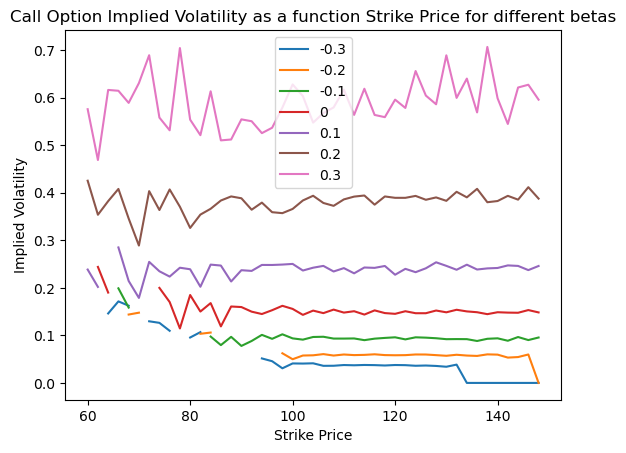

In [2]:
#To find implied volatality we solve the equation BS_price(sigma_imp) = price using a python standard root finder

def implied_vol_call(C, S, K, r, T):
    # Objective: BS price - market price = 0
    def f(sigma):
        return bs_call(S, K, sigma, T,r) - C
    try:
            result = root_scalar(f, bracket=[1e-6, 5.0], method='bisect')
            return result.root
    except Exception :
           # print(f"Solver failed for K={K}, price={C:.4f}")
            return np.nan

imp_sigma = []
for j in range(len(betas)):
    imp_sigma_beta = []
    for i in range(len(strike)):
        imp_sigma_beta.append(implied_vol_call(cp[j][i],S0,strike[i],r,T))
    #print(imp_sigma_beta)
    imp_sigma.append(imp_sigma_beta)
plt.figure()
for j in range(len(betas)):
    plt.plot(strike,imp_sigma[j],label=betas[j])
plt.legend()
plt.title('Call Option Implied Volatility as a function Strike Price for different betas')
plt.ylabel('Implied Volatility')
plt.xlabel('Strike Price')
plt.show()

The implied volatality smiles are supposed to show up for certain beta values, but we do not quite see them in this graph. It might require more parameter tuning, which I was unable to get to work.